# Welcome to PointNet& 3D CNNs Workshop!
In this workshop, we're going to learn how to voxelize a point cloud, and build a 3D Convolutional Neural Network to classify point clouds. When processing point clouds, voxel based approaches account for a good half of the existing approaches (with point based approaches being the second half) — and it's therefore important to understand how to implement them!

In [1]:
import zipfile
import os

zip_path = '/content/lidar-od-scripts.zip'
extract_path = '/content/lidar-od-scripts'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"'{zip_path}' extracted to '{extract_path}' successfully.")

# Verify extraction by listing contents
print("Contents of extracted folder:")
for root, dirs, files in os.walk(os.path.join(extract_path, 'lidar-od-scripts')):
    print(f"Directory: {root}")
    for f in files:
        print(f"  File: {f}")


'/content/lidar-od-scripts.zip' extracted to '/content/lidar-od-scripts' successfully.
Contents of extracted folder:


In [3]:
import zipfile
import os

zip_path = '/content/shapenet-core-seg/banchmark_sample.zip'
extract_path = '/content/shapenet-core-seg/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"'{zip_path}' extracted to '{extract_path}' successfully.")

# Verify extraction by listing contents
print("Contents of extracted folder:")
for root, dirs, files in os.walk(extract_path):
    print(f"Directory: {root}")
    for f in files:
        print(f"  File: {f}")

'/content/shapenet-core-seg/banchmark_sample.zip' extracted to '/content/shapenet-core-seg/' successfully.
Contents of extracted folder:
Directory: /content/shapenet-core-seg/
  File: banchmark_sample.zip
Directory: /content/shapenet-core-seg/banchmark
Directory: /content/shapenet-core-seg/banchmark/Shapenetcore_benchmark
  File: synsetoffset2category.txt
  File: test_split.json
  File: val_split.json
  File: README.txt~
  File: train_split.json
Directory: /content/shapenet-core-seg/banchmark/Shapenetcore_benchmark/03467517
Directory: /content/shapenet-core-seg/banchmark/Shapenetcore_benchmark/03467517/points_label
  File: d2938be9fd0a6cd340c20797381ee39f.seg
  File: a02ea7bcabae6de39b54ba41102517c4.seg
  File: bf038654db326b819f585e02b4e871f9.seg
  File: 7eaed9980af85df32ab677b65be9086c.seg
  File: e66d799f51f1558a2214be36f33a634a.seg
  File: ad6cab75780f3f10d57700c05b1862d8.seg
  File: bb9ec41d15fc2a1bf9412922790d06f8.seg
  File: 3338f59aefd2066f5b3335548350bdee.seg
  File: 23e9190aa

In [4]:
import json

allowed = {
"02691156",
"02958343",
"03001627",
"03467517",
"03636649",
"03790512",
"04379243"
}

def clean_file(input_path, output_path):
    with open(input_path) as f:
        data = json.load(f)

    clean = [row for row in data if row[2].split("/")[0] in allowed]

    print(input_path, "before:", len(data), "after:", len(clean))

    with open(output_path, "w") as f:
        json.dump(clean, f)

clean_file("/content/shapenet-core-seg/banchmark/Shapenetcore_benchmark/train_split.json", "/content/train_split.json")
clean_file("/content/shapenet-core-seg/banchmark/Shapenetcore_benchmark/test_split.json", "/content/test_split.json")
clean_file("/content/shapenet-core-seg/banchmark/Shapenetcore_benchmark/val_split.json", "/content/val_split.json")


/content/shapenet-core-seg/banchmark/Shapenetcore_benchmark/train_split.json before: 12137 after: 10903
/content/shapenet-core-seg/banchmark/Shapenetcore_benchmark/test_split.json before: 2848 after: 2529
/content/shapenet-core-seg/banchmark/Shapenetcore_benchmark/val_split.json before: 1861 after: 1700


In [5]:
import shutil, os

src = "/content/shapenet-core-seg/banchmark/Shapenetcore_benchmark/synsetoffset2category.txt"
dst = "/content/shapenet-core-seg/shapenet_subset/synsetoffset2category.txt"

os.makedirs(os.path.dirname(dst), exist_ok=True)
shutil.copy2(src, dst)

print("Copied to:", dst)


Copied to: /content/shapenet-core-seg/shapenet_subset/synsetoffset2category.txt


In [6]:
import os, shutil, random

SRC_ROOT = "/content/shapenet-core-seg/banchmark/Shapenetcore_benchmark"  # change if needed
DST_ROOT = "/content/shapenet-core-seg/shapenet_subset"
MAP_FILE = "/content/shapenet-core-seg/banchmark/Shapenetcore_benchmark/synsetoffset2category.txt"  # change if needed

random.seed(42)

# read synsets from the mapping file
synsets = []
with open(MAP_FILE, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        # your file looks like: "Airplane 02691156"
        syn = parts[-1]
        synsets.append(syn)

print("Synsets to process:", synsets)

def valid_ids_for_synset(syn):
    pts_dir = os.path.join(SRC_ROOT, syn, "points")
    seg_dir = os.path.join(SRC_ROOT, syn, "points_label")
    pts = {x[:-4] for x in os.listdir(pts_dir) if x.endswith(".npy")}
    seg = {x[:-4] for x in os.listdir(seg_dir) if x.endswith(".seg")}
    return sorted(list(pts & seg))

for syn in synsets:
    ids = valid_ids_for_synset(syn)

    if len(ids) < 100:
        print(f"Skipping {syn}: only {len(ids)} valid pairs")
        continue

    k = min(random.randint(100, 150), len(ids))
    chosen = random.sample(ids, k)

    dst_pts = os.path.join(DST_ROOT, syn, "points")
    dst_seg = os.path.join(DST_ROOT, syn, "points_label")
    os.makedirs(dst_pts, exist_ok=True)
    os.makedirs(dst_seg, exist_ok=True)

    for i in chosen:
        shutil.copy2(os.path.join(SRC_ROOT, syn, "points", i + ".npy"), os.path.join(dst_pts, i + ".npy"))
        shutil.copy2(os.path.join(SRC_ROOT, syn, "points_label", i + ".seg"), os.path.join(dst_seg, i + ".seg"))

    print(f"{syn}: copied {len(chosen)} pairs")


Synsets to process: ['02691156', '02958343', '03001627', '03467517', '03636649', '03790512', '04379243']
02691156: copied 140 pairs
02958343: copied 127 pairs
03001627: copied 121 pairs
03467517: copied 136 pairs
03636649: copied 122 pairs
03790512: copied 129 pairs
04379243: copied 113 pairs


In [7]:
import os, json, random
from collections import Counter

SUBSET_ROOT = "/content/shapenet-core-seg/shapenet_subset"
MAP_ROOT = "/content/shapenet-core-seg/banchmark/Shapenetcore_benchmark"
MAP_FILE = os.path.join(MAP_ROOT, "synsetoffset2category.txt")

random.seed(42)

# read mapping (format: "Airplane 02691156")
synset_to_name = {}
with open(MAP_FILE, "r") as f:
    for line in f:
        line=line.strip()
        if not line:
            continue
        parts=line.split()
        name = parts[0]
        syn  = parts[-1]
        synset_to_name[syn]=name

synsets = sorted(synset_to_name.keys())
synset_to_classid = {syn:i for i,syn in enumerate(synsets)}

def valid_ids(syn):
    pts_dir = os.path.join(SUBSET_ROOT, syn, "points")
    seg_dir = os.path.join(SUBSET_ROOT, syn, "points_label")
    pts = {x[:-4] for x in os.listdir(pts_dir) if x.endswith(".npy")}
    seg = {x[:-4] for x in os.listdir(seg_dir) if x.endswith(".seg")}
    return sorted(list(pts & seg))

train=[]; val=[]; test=[]

for syn in synsets:
    ids = valid_ids(syn)
    random.shuffle(ids)

    n = len(ids)
    ntr = int(0.7*n)
    nva = int(0.1*n)
    tr = ids[:ntr]
    va = ids[ntr:ntr+nva]
    te = ids[ntr+nva:]

    cid = synset_to_classid[syn]
    cname = synset_to_name[syn]

    train += [[cid, cname, f"{syn}/points/{i}.npy", f"{syn}/points_label/{i}.seg"] for i in tr]
    val   += [[cid, cname, f"{syn}/points/{i}.npy", f"{syn}/points_label/{i}.seg"] for i in va]
    test  += [[cid, cname, f"{syn}/points/{i}.npy", f"{syn}/points_label/{i}.seg"] for i in te]

    print(cname, syn, "total", n, "->", len(tr), len(va), len(te))

json.dump(train, open(os.path.join(SUBSET_ROOT,"train_split.json"),"w"))
json.dump(val,   open(os.path.join(SUBSET_ROOT,"val_split.json"),"w"))
json.dump(test,  open(os.path.join(SUBSET_ROOT,"test_split.json"),"w"))

print("Totals:", len(train), len(val), len(test))


Airplane 02691156 total 140 -> 98 14 28
Car 02958343 total 127 -> 88 12 27
Chair 03001627 total 121 -> 84 12 25
Guitar 03467517 total 136 -> 95 13 28
Lamp 03636649 total 122 -> 85 12 25
Motorbike 03790512 total 129 -> 90 12 27
Table 04379243 total 113 -> 79 11 23
Totals: 619 86 183


## Imports

In [8]:
# Usual Imports
import os
import sys
import json
import numpy as np
from tqdm import tqdm

# plotting library
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# append path to custom scripts
sys.path.append('./lidar-od-scripts/gpuVersion/gpuVersion')

# DL Imports
import torch
import torch.nn as nn

# custom imports
from visual_utils import plot_pc_data3d, plot_bboxes_3d

In [9]:
DATA_FOLDER = '/content/shapenet-core-seg/shapenet_subset/'

class_name_id_map = {'Airplane': 0, 'Bag': 1, 'Cap': 2, 'Car': 3, 'Chair': 4,
                'Earphone': 5, 'Guitar': 6, 'Knife': 7, 'Lamp': 8, 'Laptop': 9,
                'Motorbike': 10, 'Mug': 11, 'Pistol': 12, 'Rocket': 13,
                'Skateboard': 14, 'Table': 15}

class_id_name_map = {v:k for k,v in class_name_id_map.items()}

PCD_SCENE=dict(xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False), aspectmode='data')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Shapenet Core Dataset exploration

- Object Classification and part Segmentation Dataset from Point Cloud data
- [Shapenet core](https://shapenet.org/) is a subset of the full ShapeNet dataset
- It contains single clean 3D models, manually verified category and alignment annotations.
- 16 classes from 12 categories

In [10]:
train_split_data = json.load(open(f'{DATA_FOLDER}train_split.json', 'r'))
train_class_count = np.array([x[0] for x in train_split_data])

# plot classwise count in train set
train_dist_plots = [go.Bar(x=list(class_name_id_map.keys()), y= np.bincount(train_class_count))]
layout = dict(template="plotly_dark", title="Shapenet Core Train Distribution", title_x=0.5)
fig = go.Figure(data=train_dist_plots, layout=layout)
fig.show()

In [11]:
import glob
points_glob = os.path.join(DATA_FOLDER, "04379243", "points", "*.npy")
points_list = glob.glob(points_glob)
print(len(points_list))

113


In [12]:
import random
idx = random.randint(0,len(points_list))

# load point cloud data
points = np.load(points_list[idx])
print(f"points shape = {points.shape}, min xyz = {np.min(points, axis=0)}, max xyz = {np.max(points, axis=0)}")

# load segmentation lables
seg_file_path = points_list[idx].replace('points', 'points_label').replace('.npy', '.seg')
seg_labels = np.loadtxt(seg_file_path).astype(np.int8)
print(f"seg_labels shape = {seg_labels.shape}, unique labels = {np.unique(seg_labels)}")

points shape = (2775, 3), min xyz = [-0.3313  -0.12521 -0.35293], max xyz = [0.3313  0.12391 0.35293]
seg_labels shape = (2775,), unique labels = [1 3]


In [13]:
# there are max of 16 parts in an object in Shapenet core dataset
# creating random colors in according to part label
NUM_PARTS = 16
PART_COLORS = np.random.choice(range(255),size=(NUM_PARTS,3))

In [14]:
pc_plots = plot_pc_data3d(x=points[:,0], y=points[:,1], z=points[:,2], apply_color_gradient=False, color=PART_COLORS[seg_labels - 1], marker_size=2)
layout = dict(template="plotly_dark", title="Raw Point cloud", scene=PCD_SCENE, title_x=0.5)
fig = go.Figure(data=pc_plots, layout=layout)
fig.show()

## Build a Custom Dataset
Now that we've explored our data, we'll get more 'PyTorch friendly' and create a Dataset object, as well as a PyTorch Dataloader.

In [15]:
class ShapeNetDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, split_type, num_samples=2500):
        self.root_dir = root_dir
        self.split_type = split_type
        self.num_samples = num_samples
        with open(os.path.join(root_dir, f'{self.split_type}_split.json'), 'r') as f:
            self.split_data = json.load(f)

    def __getitem__(self, index):
        # read point cloud data
        class_id, class_name, point_cloud_path, seg_label_path = self.split_data[index]

        # point cloud data
        point_cloud_path = os.path.join(self.root_dir, point_cloud_path)
        pc_data = np.load(point_cloud_path)

        # segmentation labels
        # -1 is to change part values from [1-16] to [0-15]
        # which helps when running segmentation
        pc_seg_labels = np.loadtxt(os.path.join(self.root_dir, seg_label_path)).astype(np.int8) - 1
#         pc_seg_labels = pc_seg_labels.reshape(pc_seg_labels.size,1)

        # Sample fixed number of points
        num_points = pc_data.shape[0]
        if num_points < self.num_samples:
            # Duplicate random points if the number of points is less than max_num_points
            additional_indices = np.random.choice(num_points, self.num_samples - num_points, replace=True)
            pc_data = np.concatenate((pc_data, pc_data[additional_indices]), axis=0)
            pc_seg_labels = np.concatenate((pc_seg_labels, pc_seg_labels[additional_indices]), axis=0)

        else:
            # Randomly sample max_num_points from the available points
            random_indices = np.random.choice(num_points, self.num_samples)
            pc_data = pc_data[random_indices]
            pc_seg_labels = pc_seg_labels[random_indices]

        # return variable
        data_dict= {}
        data_dict['class_id'] = class_id
        data_dict['class_name'] = class_name
        data_dict['points'] = pc_data
        data_dict['seg_labels'] = pc_seg_labels
        return data_dict

    def __len__(self):
        return len(self.split_data)

In [16]:
train_set = ShapeNetDataset(root_dir = DATA_FOLDER, split_type='train')
val_set = ShapeNetDataset(root_dir = DATA_FOLDER, split_type='val')
test_set = ShapeNetDataset(root_dir = DATA_FOLDER, split_type='test')
print(f"Train set length = {len(train_set)}")
print(f"Validation set length = {len(val_set)}")
print(f"Test set length = {len(test_set)}")

Train set length = 619
Validation set length = 86
Test set length = 183


In [17]:
data_dict= train_set[25]
print(f"Keys in dataset sample = {list(data_dict.keys())}")
points = data_dict['points']
seg_labels = data_dict['seg_labels']
print(f"class_id = {data_dict['class_id']}, class_name = {data_dict['class_name']}")

Keys in dataset sample = ['class_id', 'class_name', 'points', 'seg_labels']
class_id = 0, class_name = Airplane


In [18]:
pc_plots = plot_pc_data3d(x=points[:,0], y=points[:,1], z=points[:,2], apply_color_gradient=False, color=PART_COLORS[seg_labels - 1], marker_size=2)
layout = dict(template="plotly_dark", title=f"{data_dict['class_name']}, class id = {data_dict['class_id']}, from Shapenetcore Torch Dataset", scene=PCD_SCENE, title_x=0.5)
fig = go.Figure(data=pc_plots, layout=layout)
fig.show()

### Data loader for Custom dataset

In [19]:
def collate_fn(batch_list):
    ret = {}
    ret['class_id'] =  torch.from_numpy(np.array([x['class_id'] for x in batch_list])).long()
    ret['class_name'] = np.array([x['class_name'] for x in batch_list])
    ret['points'] = torch.from_numpy(np.stack([x['points'] for x in batch_list], axis=0)).float()
    ret['seg_labels'] = torch.from_numpy(np.stack([x['seg_labels'] for x in batch_list], axis=0)).long()
    return ret

In [20]:
sample_loader = torch.utils.data.DataLoader(train_set, batch_size=16, num_workers=2, shuffle=True, collate_fn=collate_fn)
dataloader_iter = iter(sample_loader)
batch_dict = next(dataloader_iter)
print(batch_dict.keys())
for key in ['points','seg_labels', 'class_id']:
    print(f"batch_dict[{key}].shape = {batch_dict[key].shape}")

dict_keys(['class_id', 'class_name', 'points', 'seg_labels'])
batch_dict[points].shape = torch.Size([16, 2500, 3])
batch_dict[seg_labels].shape = torch.Size([16, 2500])
batch_dict[class_id].shape = torch.Size([16])


In [21]:
batchSize= 64
workers = 2
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batchSize, shuffle=True, num_workers=workers, collate_fn=collate_fn)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=batchSize, shuffle=True, num_workers=workers, collate_fn=collate_fn)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batchSize,shuffle=True, num_workers=workers, collate_fn=collate_fn)

# PointNet

**The model is PointNet.**<p>
![PointNet](https://d3i71xaburhd42.cloudfront.net/c3b6a072288e134f5ae6afe3eebc970ffb65cb68/3-Figure2-1.png)

It's coming from the paper: https://arxiv.org/pdf/1612.00593.pdf

The Point-Net will be done in several parts:
* T-Net
* FeatureNet
* Classification or Segmentation Head

### T-Net

In [22]:
import torch.nn.functional as F
from torch.autograd import Variable

class STN3d(nn.Module):
    """
    T-Net Model.
    STN stands for Spatial Transformer Network.
    """
    def __init__(self, num_points = 2500):
        super(STN3d, self).__init__()
        self.num_points = num_points
        self.conv1 = torch.nn.Conv1d(3, 64, 1)
        self.conv2 = torch.nn.Conv1d(64, 128, 1)
        self.conv3 = torch.nn.Conv1d(128, 1024, 1)

        self.mp1 = torch.nn.MaxPool1d(num_points)

        # FC layers
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 9)
        self.relu = nn.ReLU()

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)


    def forward(self, x):
        batchsize = x.size()[0]

        # Expected input shape = (bs, 3, num_points)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.mp1(x)
        x = x.view(-1, 1024)

        x = F.relu(self.bn4(self.fc1(x)))
        x = F.relu(self.bn5(self.fc2(x)))
        x = self.fc3(x)

        iden = Variable(torch.from_numpy(np.array([1,0,0,0,1,0,0,0,1]).astype(np.float32))).view(1,9).repeat(batchsize,1)
        if x.is_cuda:
            iden = iden.cuda()
        x = x + iden
        x = x.view(-1, 3, 3)
        return x

In [23]:
test_model = STN3d().to(device)
sim_data = Variable(torch.rand(32,3,2500)).to(device)
out = test_model(sim_data)
print('stn', out.size())

stn torch.Size([32, 3, 3])


## FeatureNet

In [ ]:
class PointNetfeat(nn.Module):
    """
    This is the T-Net for Feature Transform.
    There is also MLP part 64,128,1024.
    """
    def __init__(self, num_points = 2500, global_feat = True):
        super(PointNetfeat, self).__init__()
        self.stn = STN3d(num_points = num_points)
        self.conv1 = torch.nn.Conv1d(3, 64, 1)
        self.conv2 = torch.nn.Conv1d(64, 128, 1)
        self.conv3 = torch.nn.Conv1d(128, 1024, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.mp1 = torch.nn.MaxPool1d(num_points)
        self.num_points = num_points
        self.global_feat = global_feat

    def forward(self, x):
        batchsize = x.size()[0]
        trans = self.stn(x)
        x = x.transpose(2,1)
        x = torch.bmm(x, trans)
        x = x.transpose(2,1)
        x = F.relu(self.bn1(self.conv1(x)))
        pointfeat = x
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        x = self.mp1(x)
        x = x.view(-1, 1024)
        if self.global_feat:
            return x, trans
        else:
            x = x.view(-1, 1024, 1).repeat(1, 1, self.num_points)
            return torch.cat([x, pointfeat], 1), trans

modefied part 3.2

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PointNetfeat(nn.Module):
    """
    Modified PointNet feature extractor:
    - Neurons: 32, 64, 512 (with an extra hidden layer 128)
    - Activation: LeakyReLU
    - Pooling: Average (AdaptiveAvgPool1d)
    """
    def __init__(self, num_points=2500, global_feat=True):
        super(PointNetfeat, self).__init__()
        self.stn = STN3d(num_points=num_points)

        # MLP: 3 -> 32 -> 64 -> 128 -> 512
        self.conv1 = nn.Conv1d(3, 32, 1)
        self.conv2 = nn.Conv1d(32, 64, 1)

        # extra hidden layer
        self.conv_extra = nn.Conv1d(64, 128, 1)

        self.conv3 = nn.Conv1d(128, 512, 1)

        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn_extra = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(512)

        # avg pooling (adaptive so it works for any num_points)
        self.pool = nn.AdaptiveAvgPool1d(1)

        self.num_points = num_points
        self.global_feat = global_feat

    def forward(self, x):
        batchsize = x.size(0)

        # T-Net transform
        trans = self.stn(x)
        x = x.transpose(2, 1)          # (B, N, 3)
        x = torch.bmm(x, trans)        # (B, N, 3)
        x = x.transpose(2, 1)          # (B, 3, N)

        # LeakyReLU instead of ReLU
        x = F.leaky_relu(self.bn1(self.conv1(x)), negative_slope=0.2)
        pointfeat = x

        x = F.leaky_relu(self.bn2(self.conv2(x)), negative_slope=0.2)

        # extra hidden layer
        x = F.leaky_relu(self.bn_extra(self.conv_extra(x)), negative_slope=0.2)

        x = self.bn3(self.conv3(x))

        # avg pooling
        x = self.pool(x)               # (B, 512, 1)
        x = x.view(batchsize, 512)     # (B, 512)

        if self.global_feat:
            return x, trans
        else:
            x = x.view(batchsize, 512, 1).repeat(1, 1, self.num_points)
            return torch.cat([x, pointfeat], 1), trans

**modefied code for compare**

In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# ----------------------------
# Baseline model (uses your existing original PointNetfeat + PointNetCls)
# (From your notebook: PointNetfeat returns (global_feat, trans))
# ----------------------------

# ----------------------------
# Modified Feature Extractor (keeps T-Net, but uses 32/64/128/512 + LeakyReLU + avg pooling)
# ----------------------------
class PointNetfeat_Mod(nn.Module):
    def __init__(self, num_points=2500, global_feat=True):
        super().__init__()
        self.stn = STN3d(num_points=num_points)

        self.conv1 = nn.Conv1d(3, 32, 1)
        self.conv2 = nn.Conv1d(32, 64, 1)
        self.conv_extra = nn.Conv1d(64, 128, 1)     # extra hidden layer
        self.conv3 = nn.Conv1d(128, 512, 1)

        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn_extra = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(512)

        self.pool = nn.AdaptiveAvgPool1d(1)         # avg pooling (adaptive)

        self.num_points = num_points
        self.global_feat = global_feat

    def forward(self, x):
        B = x.size(0)

        trans = self.stn(x)          # (B,3,3)
        x = x.transpose(2,1)         # (B,N,3)
        x = torch.bmm(x, trans)      # (B,N,3)
        x = x.transpose(2,1)         # (B,3,N)

        x = F.leaky_relu(self.bn1(self.conv1(x)), negative_slope=0.2)
        pointfeat = x
        x = F.leaky_relu(self.bn2(self.conv2(x)), negative_slope=0.2)
        x = F.leaky_relu(self.bn_extra(self.conv_extra(x)), negative_slope=0.2)
        x = self.bn3(self.conv3(x))

        x = self.pool(x)             # (B,512,1)
        x = x.view(B, 512)           # (B,512)

        if self.global_feat:
            return x, trans
        else:
            x = x.view(B, 512, 1).repeat(1, 1, self.num_points)
            return torch.cat([x, pointfeat], 1), trans


# ----------------------------
# Modified Classifier (input dim 512 now + extra hidden layer + LeakyReLU)
# Returns (log_probs, trans) so we can visualize the T-Net
# ----------------------------
class PointNetCls_Mod(nn.Module):
    def __init__(self, k, num_points=2500):
        super().__init__()
        self.feat = PointNetfeat_Mod(num_points=num_points, global_feat=True)

        self.fc1 = nn.Linear(512, 512)
        self.bn1 = nn.BatchNorm1d(512)

        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc_extra = nn.Linear(256, 128)         # extra hidden layer
        self.bn_extra = nn.BatchNorm1d(128)

        self.fc3 = nn.Linear(128, k)

    def forward(self, x):
        x, trans = self.feat(x)
        x = F.leaky_relu(self.bn1(self.fc1(x)), negative_slope=0.2)
        x = F.leaky_relu(self.bn2(self.fc2(x)), negative_slope=0.2)
        x = F.leaky_relu(self.bn_extra(self.fc_extra(x)), negative_slope=0.2)
        x = self.fc3(x)
        return F.log_softmax(x, dim=-1), trans


# ----------------------------
# Train BOTH models using your existing train_model(...) that works with batch_dict
# (The function from your notebook cell 39 saves model.state_dict() at the end)
# ----------------------------
num_points = 2500
num_classes = len(class_id_name_map.items())
criterion = nn.NLLLoss()

# Baseline
model_base = PointNetCls(k=num_classes, num_points=num_points).to(device)
opt_base = optim.SGD(model_base.parameters(), lr=0.01, momentum=0.9)

_ = train_model(model_base, N_EPOCHS, criterion, opt_base, train_loader,
                label_str="class_id", output_name="pointnet_base.pth")

# Modified
model_mod = PointNetCls_Mod(k=num_classes, num_points=num_points).to(device)
opt_mod = optim.SGD(model_mod.parameters(), lr=0.01, momentum=0.9)

_ = train_model(model_mod, N_EPOCHS, criterion, opt_mod, train_loader,
                label_str="class_id", output_name="pointnet_mod.pth")

Starting 1 epoch ...


100%|██████████| 10/10 [00:02<00:00,  4.49it/s]


Epoch: 1, trainLoss:1.50264
Starting 2 epoch ...


100%|██████████| 10/10 [00:02<00:00,  4.48it/s]


Epoch: 2, trainLoss:0.34587
Starting 3 epoch ...


...

Epoch: 1, trainLoss:1.29073
Starting 2 epoch ...


100%|██████████| 10/10 [00:02<00:00,  4.20it/s]


Epoch: 2, trainLoss:0.25314
Starting 3 epoch ...


100%|██████████| 10/10 [00:02<00:00,  4.36it/s]

Epoch: 3, trainLoss:0.11236


Picked indices: [20, 3, 0]


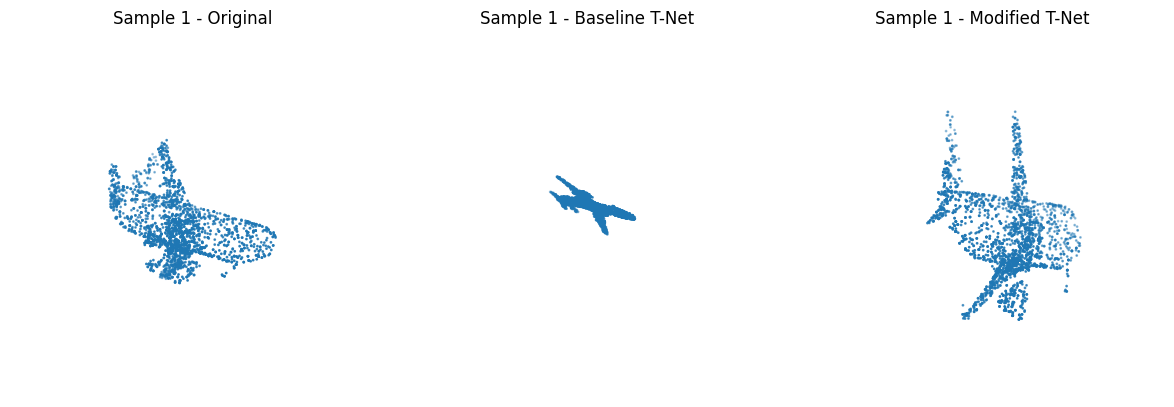


Sample 1 idx=20, class_id=0
Baseline T:
 [[ 2.3365054  -2.9535596   1.7208372 ]
 [ 0.7479825   3.1738596  -2.6689122 ]
 [ 1.077843   -0.8486095  -0.29908717]]
Modified T:
 [[ 0.1306749   0.4852594  -0.6175299 ]
 [-0.8560732   3.15861     0.6971789 ]
 [-0.03561345  0.4540641   1.285758  ]]


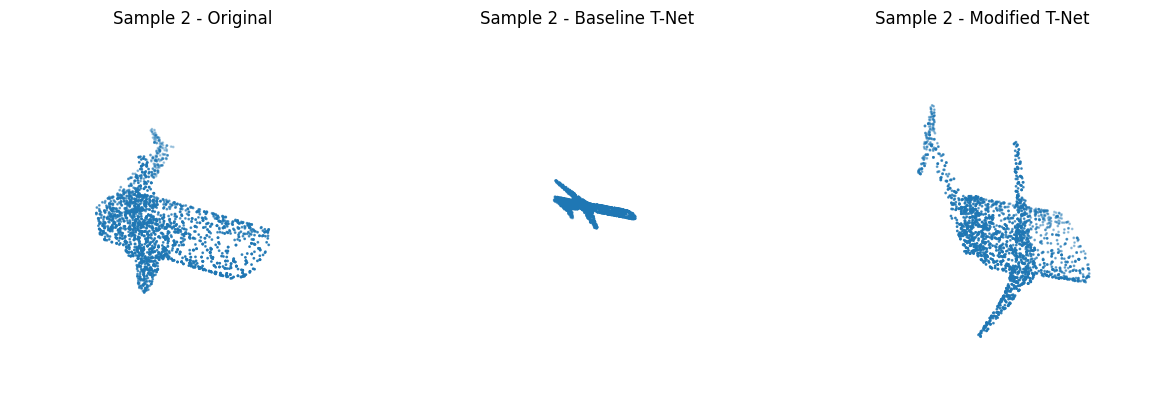


Sample 2 idx=3, class_id=0
Baseline T:
 [[ 2.3654094  -2.8551543   1.7143973 ]
 [ 0.73916143  3.1735287  -2.664409  ]
 [ 1.1104872  -0.8416637  -0.31453872]]
Modified T:
 [[ 0.05276543  0.48526233 -0.5982742 ]
 [-0.8219792   3.1221201   0.6719047 ]
 [-0.03006861  0.43243226  1.266108  ]]


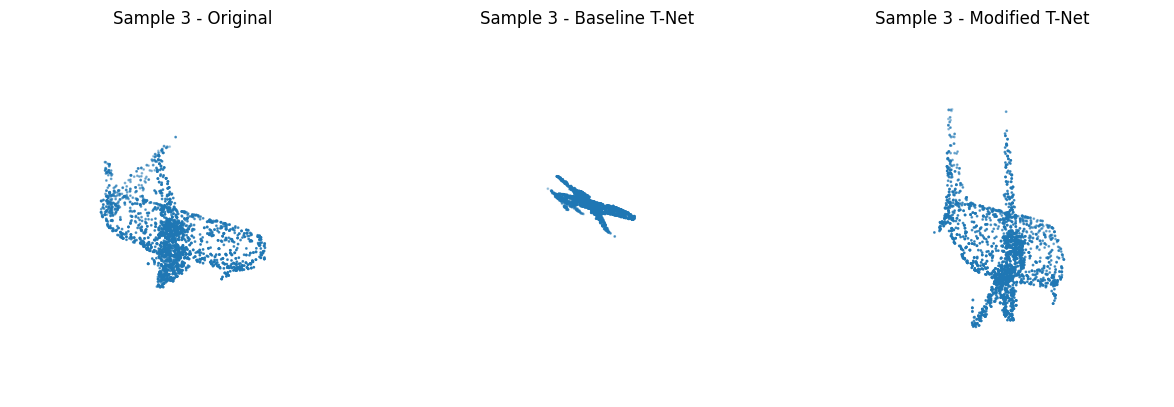


Sample 3 idx=0, class_id=0
Baseline T:
 [[ 2.3474646  -2.9361863   1.7049438 ]
 [ 0.7241701   3.1750696  -2.6428595 ]
 [ 1.0799663  -0.82897365 -0.29783177]]
Modified T:
 [[ 0.14380383  0.47085154 -0.60026616]
 [-0.8740947   3.1433697   0.7107884 ]
 [-0.04849759  0.4395364   1.268134  ]]


In [50]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

# ------------- helpers -------------
def find_k_indices_of_class(dataset, class_id, k=3, seed=0):
    random.seed(seed)
    idxs = []
    for i in range(len(dataset)):
        item = dataset[i]
        y = int(item["class_id"]) if isinstance(item, dict) else int(item[1])
        if y == class_id:
            idxs.append(i)
    if len(idxs) < k:
        raise ValueError(f"Not enough samples for class_id={class_id}. Found {len(idxs)}.")
    return random.sample(idxs, k)

def get_points_3xN(dataset, idx, device):
    item = dataset[idx]
    if isinstance(item, dict):
        pts = item["points"]      # expected (N,3)
        y = int(item["class_id"])
    else:
        pts, y = item[0], int(item[1])

    pts = torch.tensor(pts) if not torch.is_tensor(pts) else pts
    pts = pts.float()

    # convert to (3,N)
    if pts.shape[0] == 3:
        x_3xN = pts
    else:
        x_3xN = pts.transpose(0, 1)

    return x_3xN.to(device), y

def apply_tnet_to_points(x_3xN, trans_3x3):
    # x_3xN: (3,N) -> (N,3) @ (3,3) -> (N,3)
    pts_Nx3 = x_3xN.transpose(0, 1)
    return pts_Nx3 @ trans_3x3

def plot_three(axs, ptsA, ptsB, ptsC, titles):
    for ax, pts, t in zip(axs, [ptsA, ptsB, ptsC], titles):
        ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=1)
        ax.set_title(t)
        ax.set_axis_off()


# ------------- load both trained models -------------
num_points = 2500
num_classes = len(class_id_name_map.items())

model_base = PointNetCls(k=num_classes, num_points=num_points).to(device)
model_base.load_state_dict(torch.load("pointnet_base.pth", map_location=device))
model_base.eval()

model_mod = PointNetCls_Mod(k=num_classes, num_points=num_points).to(device)
model_mod.load_state_dict(torch.load("pointnet_mod.pth", map_location=device))
model_mod.eval()


# ------------- choose class + 3 samples -------------
class_id = 0           # CHANGE THIS (pick any valid class id)
k = 3
idxs = find_k_indices_of_class(test_set, class_id, k=k, seed=42)
print("Picked indices:", idxs)

# ------------- visualize -------------
with torch.no_grad():
    for j, idx in enumerate(idxs, start=1):
        x_3xN, y = get_points_3xN(test_set, idx, device)        # (3,N)
        X = x_3xN.unsqueeze(0)                                  # (1,3,N)

        # ORIGINAL (no transform)
        pts_orig = x_3xN.transpose(0, 1).cpu().numpy()          # (N,3)

        # Baseline T-Net transform
        pred_b, trans_b = model_base(X)                         # trans_b: (1,3,3)
        pts_b = apply_tnet_to_points(x_3xN, trans_b.squeeze(0)).cpu().numpy()

        # Modified T-Net transform
        pred_m, trans_m = model_mod(X)
        pts_m = apply_tnet_to_points(x_3xN, trans_m.squeeze(0)).cpu().numpy()

        fig = plt.figure(figsize=(12,4))
        axs = [fig.add_subplot(1,3,i+1, projection="3d") for i in range(3)]
        plot_three(
            axs,
            pts_orig, pts_b, pts_m,
            [f"Sample {j} - Original",
             f"Sample {j} - Baseline T-Net",
             f"Sample {j} - Modified T-Net"]
        )
        plt.tight_layout()
        plt.show()

        print(f"\nSample {j} idx={idx}, class_id={y}")
        print("Baseline T:\n", trans_b.squeeze(0).cpu().numpy())
        print("Modified T:\n", trans_m.squeeze(0).cpu().numpy())

**end modefied code**

In [27]:
pointfeat = PointNetfeat(global_feat=True).to(device)
out, _ = pointfeat(sim_data)
print('global feat', out.size())

pointfeat = PointNetfeat(global_feat=False).to(device)
out, _ = pointfeat(sim_data)
print('point feat', out.size())

global feat torch.Size([32, 512])
point feat torch.Size([32, 544, 2500])


## Classifier Head

In [28]:
class PointNetCls(nn.Module):
    """
    Network for Classification: 512, 256, K.
    """
    def __init__(self, num_points = 2500, k = 2):
        super(PointNetCls, self).__init__()
        self.num_points = num_points
        self.feat = PointNetfeat(num_points, global_feat=True)
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, k)
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.relu = nn.ReLU()
    def forward(self, x):
        x, trans = self.feat(x)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.fc3(x)
        return F.log_softmax(x, dim=-1), trans

modefied 3.2

In [30]:
class PointNetCls(nn.Module):
    def __init__(self, k, num_points=2500):
        super().__init__()
        self.feat = PointNetfeat(num_points=num_points, global_feat=True)

        self.fc1 = nn.Linear(512, 512)
        self.bn1 = nn.BatchNorm1d(512)

        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc_extra = nn.Linear(256, 128)         # extra hidden layer
        self.bn_extra = nn.BatchNorm1d(128)

        self.fc3 = nn.Linear(128, k)

    def forward(self, x):
        x, trans = self.feat(x)
        x = F.leaky_relu(self.bn1(self.fc1(x)), negative_slope=0.2)
        x = F.leaky_relu(self.bn2(self.fc2(x)), negative_slope=0.2)
        x = F.leaky_relu(self.bn_extra(self.fc_extra(x)), negative_slope=0.2)
        x = self.fc3(x)
        return F.log_softmax(x, dim=-1), trans


In [31]:
cls = PointNetCls(k = 16).to(device)
out, _ = cls(sim_data)
print('class', out.size())

class torch.Size([32, 16])


## Training

In [32]:
def train_model(model, num_epochs, criterion, optimizer, dataloader_train,
                label_str = 'class_id', lr_scheduler = None, output_name = 'pointnet.pth'):
    # move model to device
    model.to(device)

    for epoch in range(num_epochs):
        print(f"Starting {epoch + 1} epoch ...")

        # Training
        model.train()
        train_loss = 0.0
        for batch_dict in tqdm(dataloader_train, total=len(dataloader_train)):
            # Forward pass
            x = batch_dict['points'].transpose(1, 2).to(device)
            labels = batch_dict[label_str].to(device)
            pred, _ = model(x)
            loss = criterion(pred, labels)
            train_loss += loss.item()

            # Backward pass
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # adjust learning rate
            if lr_scheduler is not None:
                lr_scheduler.step()

        # compute per batch losses, metric value
        train_loss = train_loss / len(dataloader_train)

        print(f'Epoch: {epoch+1}, trainLoss:{train_loss:6.5f}')
    torch.save(model.state_dict(), output_name)

In [33]:
import torch.optim as optim

N_EPOCHS = 3
num_points = 2500
num_classes = 16
criterion = nn.NLLLoss()

# create model, optimizer, lr_scheduler and pass to training function
num_classes = len(class_id_name_map.items())
classifier = PointNetCls(k = num_classes, num_points = num_points)

# DEFINE OPTIMIZERS
optimizer = optim.SGD(classifier.parameters(), lr=0.01, momentum=0.9)
if torch.cuda.is_available():
    classifier.cuda()


_ = train_model(classifier, N_EPOCHS, criterion, optimizer, train_loader)

Starting 1 epoch ...


100%|██████████| 10/10 [00:02<00:00,  4.17it/s]


Epoch: 1, trainLoss:1.39693
Starting 2 epoch ...


100%|██████████| 10/10 [00:02<00:00,  4.59it/s]


Epoch: 2, trainLoss:0.31845
Starting 3 epoch ...


100%|██████████| 10/10 [00:02<00:00,  4.36it/s]

Epoch: 3, trainLoss:0.13743


## Inference

In [34]:
classifier = PointNetCls(k=num_classes).to(device)
classifier.load_state_dict(torch.load('pointnet.pth'))
classifier.eval()

total_loss = 0.0

with torch.no_grad():
    for batch_dict in tqdm(test_loader, total=len(test_loader)):
        x = batch_dict['points'].transpose(1, 2).to(device)
        labels = batch_dict['class_id'].to(device)
        pred, _ = classifier(x)

        # calculate loss
        loss = criterion(pred, labels)
        total_loss += loss.item()

evaluation_loss = total_loss / len(test_loader)
print(evaluation_loss)

100%|██████████| 3/3 [00:00<00:00,  6.27it/s]

2.399547576904297


## Test on individual items

In [35]:
# Random test sample
test_sample = test_set[np.random.choice(np.arange(len(test_set)))]
batch_dict = collate_fn([test_sample])
x = batch_dict['points'].transpose(1, 2).to(device)

# Get model predictions
model_preds, _ = classifier(x)
predicted_class = torch.argmax(model_preds, axis=1).detach().cpu().numpy()[0]
predicted_class_name = class_id_name_map[predicted_class]
pred_class_probs = F.softmax(model_preds.flatten(), dim=None).detach().cpu().numpy()

# plot results
title = f"Label = {test_sample['class_name']}, Predicted class = {predicted_class_name}"
fig = make_subplots(rows=1, cols=2, specs=[[{"type": "scatter3d"}, {}]], column_widths=[0.4, 0.6])
fig.update_layout(template="plotly_dark", scene=PCD_SCENE, height = 400, width = 1200,
                title=title, title_x=0.1, title_y=0.97, margin=dict(r=0, b=0, l=0, t=0))
fig.add_trace(plot_pc_data3d(x=test_sample['points'][:,0], y=test_sample['points'][:,1], z=test_sample['points'][:,2]), row=1, col=1)
fig.add_trace(go.Bar(x=list(class_name_id_map.keys()), y=pred_class_probs, showlegend=False), row=1, col=2)
fig.show()

/tmp/ipython-input-3837583052.py:10: UserWarning:

Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.



## Segmentation

In [36]:
class PointNetDenseCls(nn.Module):
    """
    Network for Segmentation
    """
    def __init__(self, num_points = 2500, k = 2):
        super(PointNetDenseCls, self).__init__()
        self.num_points = num_points
        self.k = k
        self.feat = PointNetfeat(num_points, global_feat=False)
        self.conv1 = torch.nn.Conv1d(1088, 512, 1)
        self.conv2 = torch.nn.Conv1d(512, 256, 1)
        self.conv3 = torch.nn.Conv1d(256, 128, 1)
        self.conv4 = torch.nn.Conv1d(128, self.k, 1)
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.bn3 = nn.BatchNorm1d(128)

    def forward(self, x):
        batchsize = x.size()[0]
        x, trans = self.feat(x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.conv4(x)
        return x, trans

modefied 3.2

In [43]:
class PointNetDenseCls(nn.Module):
    """
    Network for Segmentation
    """
    def __init__(self, num_points = 2500, k = 2):
        super(PointNetDenseCls, self).__init__()
        self.num_points = num_points
        self.k = k

        # IMPORTANT: use the modified feature extractor with global_feat=False
        self.feat = PointNetfeat(num_points=num_points, global_feat=False)

        # Input channels changed: 512 (global) + 32 (pointfeat after conv1) = 544
        self.conv1 = nn.Conv1d(544, 256, 1)
        self.conv2 = nn.Conv1d(256, 128, 1)
        self.conv3 = nn.Conv1d(128, 64, 1)
        self.conv4 = nn.Conv1d(64, self.k, 1)

        self.bn1 = nn.BatchNorm1d(256)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(64)

    def forward(self, x):
        batchsize = x.size(0)

        x, trans = self.feat(x)  # x: (B, 544, N), trans: (B, 3, 3)

        x = F.leaky_relu(self.bn1(self.conv1(x)), negative_slope=0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), negative_slope=0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), negative_slope=0.2)
        x = self.conv4(x)  # (B, k, N)

        return x, trans

In [44]:
seg = PointNetDenseCls(k = 16).to(device)
print(seg)
out, _ = seg(sim_data)
print('seg', out.size())

PointNetDenseCls(
  (feat): PointNetfeat(
    (stn): STN3d(
      (conv1): Conv1d(3, 64, kernel_size=(1,), stride=(1,))
      (conv2): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
      (conv3): Conv1d(128, 1024, kernel_size=(1,), stride=(1,))
      (mp1): MaxPool1d(kernel_size=2500, stride=2500, padding=0, dilation=1, ceil_mode=False)
      (fc1): Linear(in_features=1024, out_features=512, bias=True)
      (fc2): Linear(in_features=512, out_features=256, bias=True)
      (fc3): Linear(in_features=256, out_features=9, bias=True)
      (relu): ReLU()
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn3): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True

## Training segmentation model

In [45]:
N_EPOCHS = 3
num_points = 2500
criterion = nn.CrossEntropyLoss()

# create model, optimizer, lr_scheduler and pass to training function
num_classes = len(class_id_name_map.items())
dense_classifier = PointNetDenseCls(k = NUM_PARTS, num_points = num_points)
dense_classifier.to(device)

# DEFINE OPTIMIZERS
optimizer = optim.SGD(dense_classifier.parameters(), lr=0.01, momentum=0.9)

train_model(dense_classifier, N_EPOCHS, criterion, optimizer, train_loader,
            label_str='seg_labels', output_name='pointnet_seg.pth')

Starting 1 epoch ...


100%|██████████| 10/10 [00:02<00:00,  3.34it/s]


Epoch: 1, trainLoss:2.18176
Starting 2 epoch ...


100%|██████████| 10/10 [00:02<00:00,  3.34it/s]


Epoch: 2, trainLoss:1.30064
Starting 3 epoch ...


100%|██████████| 10/10 [00:03<00:00,  3.30it/s]

Epoch: 3, trainLoss:0.92832


## Inference

In [46]:
dense_classifier.load_state_dict(torch.load('pointnet_seg.pth'))
dense_classifier.eval()

total_loss = 0.0

with torch.no_grad():
    for batch_dict in tqdm(test_loader, total=len(test_loader)):
        x = batch_dict['points'].transpose(1, 2).to(device)
        labels = batch_dict['seg_labels'].to(device)
        pred, _ = dense_classifier(x)

        # calculate loss
        loss = criterion(pred, labels)
        total_loss += loss.item()

evaluation_loss = total_loss / len(test_loader)
print(evaluation_loss)

100%|██████████| 3/3 [00:00<00:00,  5.27it/s]

1.7753743728001912


## Test on individual items

In [47]:
# Random test sample
test_sample = test_set[np.random.choice(np.arange(len(test_set)))]
batch_dict = collate_fn([test_sample])

# Get model predictions
x = batch_dict['points'].transpose(1, 2).to(device)
model_preds, _ = dense_classifier(x)
pred_part_labels = torch.argmax(model_preds, axis=1).detach().cpu().numpy()[0]

points = test_sample['points']
part_labels = test_sample['seg_labels']


# plot results
fig = make_subplots(rows=1, cols=2, specs=[[{"type": "scatter3d"}, {"type": "scatter3d"}]], column_widths=[0.5, 0.5],
                    subplot_titles=('Part Labels', 'Part Predictions'))

# ground truth part labels
part_label_plots = plot_pc_data3d(x=points[:,0], y=points[:,1], z=points[:,2], apply_color_gradient=False,
                                  color=PART_COLORS[part_labels - 1], marker_size=2)

# ground truth part labels
pred_part_label_plots = plot_pc_data3d(x=points[:,0], y=points[:,1], z=points[:,2], apply_color_gradient=False,
                                  color=PART_COLORS[pred_part_labels - 1], marker_size=2)

fig.update_layout(template="plotly_dark", scene=PCD_SCENE, scene2=PCD_SCENE, height = 400, width = 1200,
                title='PointNet Segmentation', title_x=0.5, title_y=0.97, margin=dict(r=0, b=0, l=0, t=0))
fig.add_trace(part_label_plots, row=1, col=1)
fig.add_trace(pred_part_label_plots, row=1, col=2)
fig.show()

# pointnet updated task 3.2

**TNET**

In [48]:
import torch.nn.functional as F
from torch.autograd import Variable

class STN3d(nn.Module):
    """
    T-Net Model.
    STN stands for Spatial Transformer Network.
    """
    def __init__(self, num_points = 2500):
        super(STN3d, self).__init__()
        self.num_points = num_points
        self.conv1 = torch.nn.Conv1d(3, 64, 1)
        self.conv2 = torch.nn.Conv1d(64, 128, 1)
        self.conv3 = torch.nn.Conv1d(128, 1024, 1)

        self.mp1 = torch.nn.MaxPool1d(num_points)

        # FC layers
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 9)
        self.relu = nn.ReLU()

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)


    def forward(self, x):
        batchsize = x.size()[0]

        # Expected input shape = (bs, 3, num_points)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.mp1(x)
        x = x.view(-1, 1024)

        x = F.relu(self.bn4(self.fc1(x)))
        x = F.relu(self.bn5(self.fc2(x)))
        x = self.fc3(x)

        iden = Variable(torch.from_numpy(np.array([1,0,0,0,1,0,0,0,1]).astype(np.float32))).view(1,9).repeat(batchsize,1)
        if x.is_cuda:
            iden = iden.cuda()
        x = x + iden
        x = x.view(-1, 3, 3)
        return x

In [ ]:
test_model = STN3d().to(device)
sim_data = Variable(torch.rand(32,3,2500)).to(device)
out = test_model(sim_data)
print('stn', out.size())

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PointNetfeat(nn.Module):
    """
    Feature extractor (with input transform T-Net via STN3d).
    Modified MLP: (32, 64, 128, 512)
    Activation: LeakyReLU
    Pooling: AdaptiveAvgPool1d
    """
    def __init__(self, num_points=2500, global_feat=True):
        super(PointNetfeat, self).__init__()
        self.stn = STN3d(num_points=num_points)

        # MLP (shared across points): 3 -> 32 -> 64 -> 128 -> 512
        self.conv1 = nn.Conv1d(3, 32, 1)
        self.conv2 = nn.Conv1d(32, 64, 1)

        # extra hidden layer
        self.conv_extra = nn.Conv1d(64, 128, 1)

        self.conv3 = nn.Conv1d(128, 512, 1)

        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn_extra = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(512)

        # pooling: average (adaptive so it doesn't depend on num_points)
        self.pool = nn.AdaptiveAvgPool1d(1)

        self.num_points = num_points
        self.global_feat = global_feat

    def forward(self, x):
        batchsize = x.size(0)

        # input transform
        trans = self.stn(x)
        x = x.transpose(2, 1)              # (bs, n, 3)
        x = torch.bmm(x, trans)            # (bs, n, 3)
        x = x.transpose(2, 1)              # (bs, 3, n)

        # LeakyReLU activations
        x = F.leaky_relu(self.bn1(self.conv1(x)), negative_slope=0.2)
        pointfeat = x

        x = F.leaky_relu(self.bn2(self.conv2(x)), negative_slope=0.2)

        # extra hidden layer
        x = F.leaky_relu(self.bn_extra(self.conv_extra(x)), negative_slope=0.2)

        x = self.bn3(self.conv3(x))

        # avg pooling -> (bs, 512, 1)
        x = self.pool(x)

        # global feature vector -> (bs, 512)
        x = x.view(batchsize, 512)

        if self.global_feat:
            return x, trans
        else:
            # expand global feature and concatenate with point features
            x = x.view(batchsize, 512, 1).repeat(1, 1, self.num_points)
            return torch.cat([x, pointfeat], 1), trans

# **Task 3.1**

cloning to two subsets

In [ ]:
import os, shutil

BASE_SUBSET = "/content/shapenet-core-seg/shapenet_subset"
SUBSET1 = "/content/shapenet-core-seg/shapenet_subset_ortho"
SUBSET2 = "/content/shapenet-core-seg/shapenet_subset_rot_persp"

for dst in [SUBSET1, SUBSET2]:
    if os.path.exists(dst):
        shutil.rmtree(dst)
    shutil.copytree(BASE_SUBSET, dst)

print("Cloned to:", SUBSET1)
print("Cloned to:", SUBSET2)


Cloned to: /content/shapenet-core-seg/shapenet_subset_ortho
Cloned to: /content/shapenet-core-seg/shapenet_subset_rot_persp


Orthographic Projection on subset 1

In [ ]:
import os, numpy as np, random

random.seed(42)
np.random.seed(42)

SUBSET1 = "/content/shapenet-core-seg/shapenet_subset_ortho"

def apply_orthographic_projection(root):
    synsets = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d)) and d.isdigit()]
    total = 0
    for syn in synsets:
        pts_dir = os.path.join(root, syn, "points")
        for fn in os.listdir(pts_dir):
            if not fn.endswith(".npy"):
                continue
            path = os.path.join(pts_dir, fn)
            pts = np.load(path)              # (N,3)
            drop_axis = random.randint(0, 2) # 0=x,1=y,2=z
            pts[:, drop_axis] = 0.0          # orthographic projection
            np.save(path, pts)
            total += 1
    print("Orthographic projection applied to", total, "point-cloud files.")

apply_orthographic_projection(SUBSET1)


Orthographic projection applied to 888 point-cloud files.


rotation + perspective

In [ ]:
import os, numpy as np, random

random.seed(42)
np.random.seed(42)

SUBSET2 = "/content/shapenet-core-seg/shapenet_subset_rot_persp"

def random_rotation_matrix():
    theta = random.uniform(0, 2*np.pi)
    axis = random.choice(["x","y","z"])
    c, s = np.cos(theta), np.sin(theta)

    if axis == "x":
        R = np.array([[1,0,0],[0,c,-s],[0,s,c]], dtype=np.float32)
    elif axis == "y":
        R = np.array([[c,0,s],[0,1,0],[-s,0,c]], dtype=np.float32)
    else:  # z
        R = np.array([[c,-s,0],[s,c,0],[0,0,1]], dtype=np.float32)
    return R

def apply_rot_persp(root, d=5.0, eps=1e-6):
    synsets = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d)) and d.isdigit()]
    total = 0

    for syn in synsets:
        pts_dir = os.path.join(root, syn, "points")
        for fn in os.listdir(pts_dir):
            if not fn.endswith(".npy"):
                continue
            path = os.path.join(pts_dir, fn)
            pts = np.load(path).astype(np.float32)   # (N,3)

            # 1) random rotation
            R = random_rotation_matrix()
            pts = pts @ R.T

            # 2) random perspective projection onto a random plane
            # choose which axis is the "depth" axis (we divide by it)
            depth_axis = random.randint(0,2)  # 0=x,1=y,2=z
            keep_axes = [i for i in range(3) if i != depth_axis]

            depth = pts[:, depth_axis] + d
            depth = np.where(np.abs(depth) < eps, eps, depth)

            proj2d = pts[:, keep_axes] / depth[:, None]  # (N,2)

            # 3) store back as (N,3) for PointNet
            out = np.zeros_like(pts)
            out[:, keep_axes] = proj2d
            out[:, depth_axis] = 0.0

            np.save(path, out)
            total += 1

    print("Rotation + perspective projection applied to", total, "point-cloud files.")

apply_rot_persp(SUBSET2)


Rotation + perspective projection applied to 888 point-cloud files.


new trainsets

In [ ]:
import os, json, random
from collections import Counter

random.seed(42)

def make_splits(root):
    map_file = os.path.join(root, "synsetoffset2category.txt")
    out_dir = os.path.join(root, "train_test_split_subset")
    os.makedirs(out_dir, exist_ok=True)

    synset_to_name = {}
    with open(map_file, "r") as f:
        for line in f:
            line=line.strip()
            if not line:
                continue
            parts=line.split()
            name = parts[0]
            syn  = parts[-1]
            synset_to_name[syn]=name

    synsets = sorted(synset_to_name.keys())
    synset_to_classid = {syn:i for i,syn in enumerate(synsets)}

    def valid_ids(syn):
        pts_dir = os.path.join(root, syn, "points")
        seg_dir = os.path.join(root, syn, "points_label")
        pts = {x[:-4] for x in os.listdir(pts_dir) if x.endswith(".npy")}
        seg = {x[:-4] for x in os.listdir(seg_dir) if x.endswith(".seg")}
        return sorted(list(pts & seg))

    train=[]; val=[]; test=[]
    for syn in synsets:
        ids = valid_ids(syn)
        random.shuffle(ids)

        n = len(ids)
        ntr = int(0.7*n)
        nva = int(0.1*n)
        tr = ids[:ntr]
        va = ids[ntr:ntr+nva]
        te = ids[ntr+nva:]

        cid = synset_to_classid[syn]
        cname = synset_to_name[syn]

        train += [[cid, cname, f"{syn}/points/{i}.npy", f"{syn}/points_label/{i}.seg"] for i in tr]
        val   += [[cid, cname, f"{syn}/points/{i}.npy", f"{syn}/points_label/{i}.seg"] for i in va]
        test  += [[cid, cname, f"{syn}/points/{i}.npy", f"{syn}/points_label/{i}.seg"] for i in te]

        print(f"[{os.path.basename(root)}] {cname} {syn}: total={n} -> {len(tr)}/{len(va)}/{len(te)}")

    json.dump(train, open(os.path.join(out_dir,"train_split.json"),"w"))
    json.dump(val,   open(os.path.join(out_dir,"val_split.json"),"w"))
    json.dump(test,  open(os.path.join(out_dir,"test_split.json"),"w"))

    print(f"[{os.path.basename(root)}] totals:", len(train), len(val), len(test))
    return out_dir

BASE_SUBSET = "/content/shapenet-core-seg/shapenet_subset"
SUBSET1 = "/content/shapenet-core-seg/shapenet_subset_ortho"
SUBSET2 = "/content/shapenet-core-seg/shapenet_subset_rot_persp"

base_splits = make_splits(BASE_SUBSET)
ortho_splits = make_splits(SUBSET1)
rotpersp_splits = make_splits(SUBSET2)


[shapenet_subset] Airplane 02691156: total=140 -> 98/14/28
[shapenet_subset] Car 02958343: total=127 -> 88/12/27
[shapenet_subset] Chair 03001627: total=121 -> 84/12/25
[shapenet_subset] Guitar 03467517: total=136 -> 95/13/28
[shapenet_subset] Lamp 03636649: total=122 -> 85/12/25
[shapenet_subset] Motorbike 03790512: total=129 -> 90/12/27
[shapenet_subset] Table 04379243: total=113 -> 79/11/23
[shapenet_subset] totals: 619 86 183
[shapenet_subset_ortho] Airplane 02691156: total=140 -> 98/14/28
[shapenet_subset_ortho] Car 02958343: total=127 -> 88/12/27
[shapenet_subset_ortho] Chair 03001627: total=121 -> 84/12/25
[shapenet_subset_ortho] Guitar 03467517: total=136 -> 95/13/28
[shapenet_subset_ortho] Lamp 03636649: total=122 -> 85/12/25
[shapenet_subset_ortho] Motorbike 03790512: total=129 -> 90/12/27
[shapenet_subset_ortho] Table 04379243: total=113 -> 79/11/23
[shapenet_subset_ortho] totals: 619 86 183
[shapenet_subset_rot_persp] Airplane 02691156: total=140 -> 98/14/28
[shapenet_subse